In [126]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import numpy as np
# pip install phik
import phik # Библиотека для построения матрицы корелляции между переменными
from phik.report import plot_correlation_matrix

In [127]:
df = pd.read_json("baikal_data.json")
print(f"Строк: {df.shape[0]}, Столбцов: {df.shape[1]}")
df.head()

Строк: 1100, Столбцов: 10


,ID,Животное,Тип,Место наблюдения,Сезон,Количество особей,Температура воздуха (°C),Тип питания,Антропогенный фактор,Интересный факт
0,1,Омуль,рыба,Чивыркуйский залив,весна,83.0,-5.945668,всеядный,загрязнение,"Символ Байкала, нерестится в реках осенью"
1,2,Голомянка,рыба,Чивыркуйский залив,осень,224.0,9.245049,хищник,загрязнение,Уникальная живородящая рыба с прозрачным телом
2,3,Чайка,птица,Селенгинский район,зима,1.0,-19.465447,хищник,нет влияния,"Гнездится колониями на скалах, питается рыбой"
3,4,Нерпа,млекопитающее,Селенгинский район,осень,6.0,14.569795,хищник,загрязнение,"Единственное млекопитающее Байкала, может ныря..."
4,5,Чайка,птица,Ольхон,осень,3.0,-3.955328,хищник,рыболовство,"Гнездится колониями на скалах, питается рыбой"


In [128]:
df.info()

<class 'pandas.DataFrame'>
Index: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1100 non-null   int64  
 1   Животное                  1100 non-null   str    
 2   Тип                       1100 non-null   str    
 3   Место наблюдения          1100 non-null   str    
 4   Сезон                     1100 non-null   str    
 5   Количество особей         1099 non-null   float64
 6   Температура воздуха (°C)  1097 non-null   float64
 7   Тип питания               1100 non-null   str    
 8   Антропогенный фактор      1100 non-null   str    
 9   Интересный факт           1100 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 94.5 KB


#### Первое знакомство с данными
  1. ID — Уникальный номер записи.
  2. Животное — Вид животного.
  3. Тип — Биологический класс/группа.
  4. Место наблюдения — Локация встречи.
  5. Сезон — Время года.
  6. Количество особей — Число замеченных животных.
  7. Температура воздуха (°C) — Температура при наблюдении.
  8. Тип питания — Пищевая специализация.
  9. Антропогенный фактор — Влияние человека.
  10. Интересный факт — Особенность вида.

In [129]:
df.describe()

,ID,Количество особей,Температура воздуха (°C)
count,1100.000000,1099.000000,1097.000000
mean,550.500000,985.754322,-1.605929
std,317.686953,2329.403210,12.794733
min,1.000000,0.000000,-24.932808
25%,275.750000,8.000000,-12.694100
50%,550.500000,85.000000,-1.773593
75%,825.250000,330.500000,10.296396
max,1100.000000,14817.000000,19.981301


In [130]:
num_data = []
categ_data = []
for col in df:
  if  len(df[col].unique()) / df[col].shape[0] > 0.05:
    num_data.append(col)
  else:
    categ_data.append(col)
print(num_data)
print(categ_data)

['ID', 'Количество особей', 'Температура воздуха (°C)']
['Животное', 'Тип', 'Место наблюдения', 'Сезон', 'Тип питания', 'Антропогенный фактор', 'Интересный факт']


#### Типы данных
  1. String — Животное, Тип, Место наблюдения, Сезон, Тип питания, Антропогенный фактор, Интересный факт.
  2. Float (Числовые) — Количество особей, Температура воздуха (°C).   

In [131]:
print(f"Всего пропусков {int(df.isna().sum().sum())}")
df_missing = df[df.isna().any(axis=1)]
print(df_missing)

Всего пропусков 4
      ID Животное    Тип    Место наблюдения  Сезон  Количество особей  \
180  181    Чайка  птица              Ольхон  весна               15.0   
404  405    Чайка  птица              Ольхон   лето                NaN   
421  422    Чайка  птица  Чивыркуйский залив   лето               24.0   
575  576    Чайка  птица  Баргузинский залив  осень               18.0   

     Температура воздуха (°C) Тип питания Антропогенный фактор  \
180                       NaN      хищник              туристы   
404                 18.594933      хищник          рыболовство   
421                       NaN      хищник              туристы   
575                       NaN      хищник              туристы   

                                   Интересный факт  
180  Гнездится колониями на скалах, питается рыбой  
404  Гнездится колониями на скалах, питается рыбой  
421  Гнездится колониями на скалах, питается рыбой  
575  Гнездится колониями на скалах, питается рыбой  


#### Анализ пропусков

1. **Локализация**: Пропуски обнаружены исключительно в числовых переменных (`Количество особей` и `Температура воздуха`). Категориальные данные заполнены полностью.
2. **Стратегия заполнения**:
   - Простое удаление строк нежелательно, так как данных немного.
   - Заполнение общим средним некорректно из-за сезонности и видовых различий.
   - **Решение**: Заполнить пропуски **медианными значениями**, сгруппированными по похожести наблюдений (например, температура для того же *Сезона*, количество для того же *Вида животного*).

In [132]:
df['Температура воздуха (°C)'] = df['Температура воздуха (°C)'].fillna(
    df.groupby('Сезон')['Температура воздуха (°C)'].transform('median')
)

df['Количество особей'] = df['Количество особей'].fillna(
    df.groupby('Животное')['Количество особей'].transform('median')
)

print(f"Осталось пропусков: {df.isna().sum().sum()}")

Осталось пропусков: 0


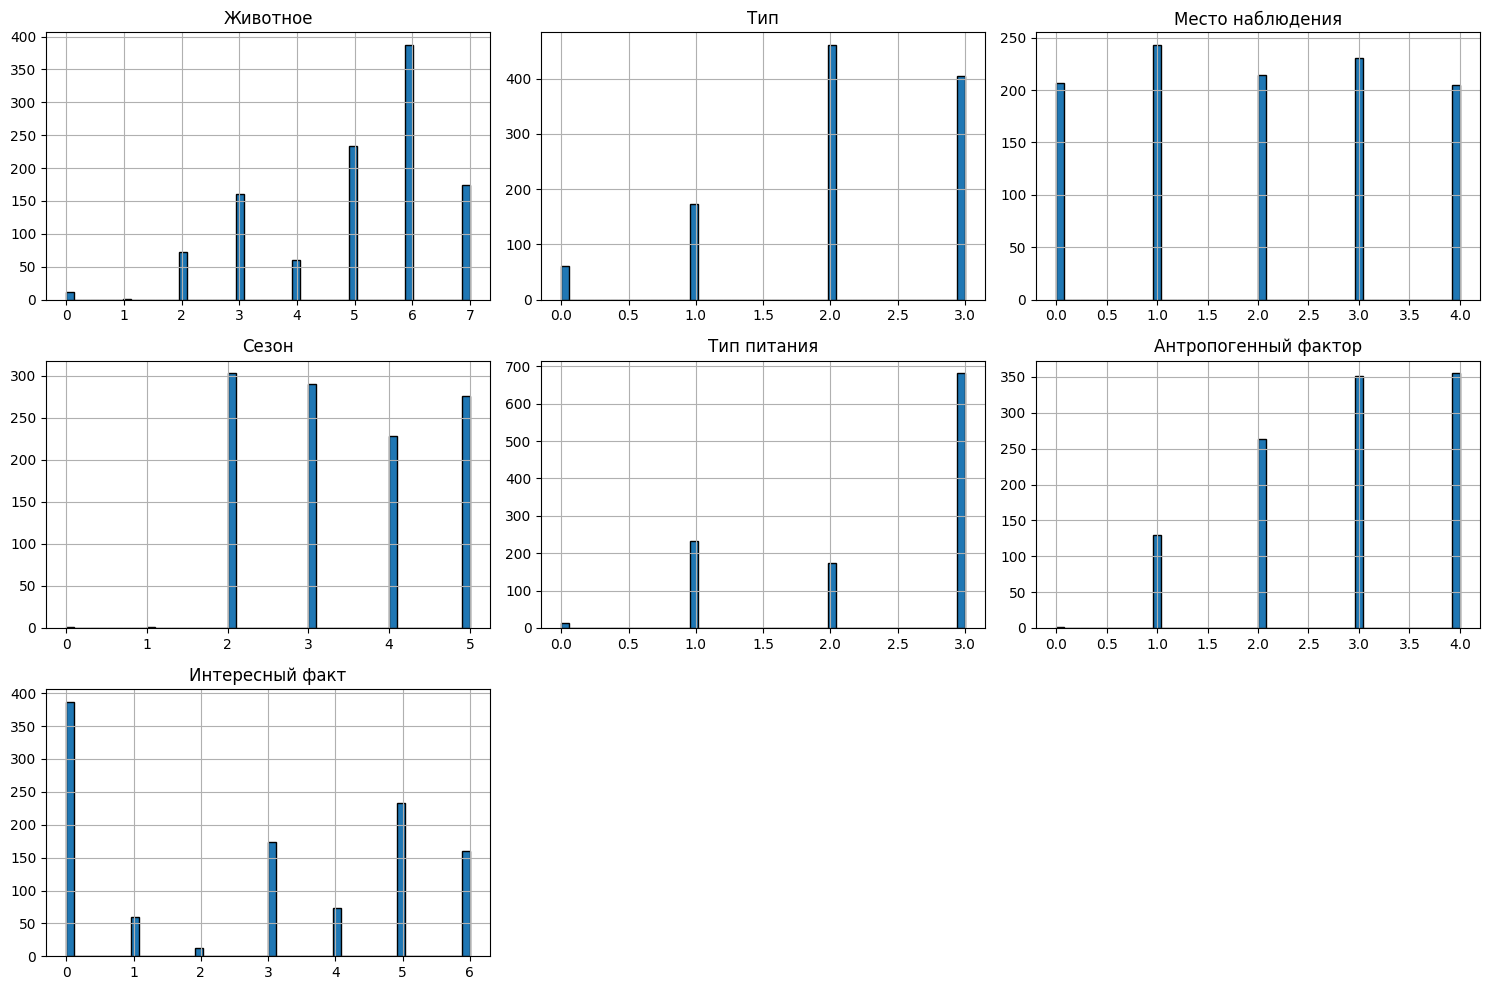

Колонка — Животное
['Байкальский осетр', 'Баклан', 'Большой баклан', 'Голомянка', 'Нерпа', 'Омуль', 'Чайка', 'Эпишура']
--------------------------------------------------
Колонка — Тип
['млекопитающее', 'планктон', 'птица', 'рыба']
--------------------------------------------------
Колонка — Место наблюдения
['Баргузинский залив', 'Малое Море', 'Ольхон', 'Селенгинский район', 'Чивыркуйский залив']
--------------------------------------------------
Колонка — Сезон
['Лето', 'Осень', 'весна', 'зима', 'лето', 'осень']
--------------------------------------------------
Колонка — Тип питания
['бентофаг', 'всеядный', 'фильтратор', 'хищник']
--------------------------------------------------
Колонка — Антропогенный фактор
['НЕТ', 'загрязнение', 'нет влияния', 'рыболовство', 'туристы']
--------------------------------------------------
Колонка — Интересный факт
['Гнездится колониями на скалах, питается рыбой', 'Единственное млекопитающее Байкала, может нырять на 300 метров!', 'Занесен в Красную

In [133]:
def data_categ_visualization(df, num_data):
  df_copy = df.copy()
  
  for col in df_copy.columns:
    if col in num_data:
      df_copy = df_copy.drop(col, axis=1)
    else:
      lb = LabelEncoder()
      df_copy[col] = lb.fit_transform(df_copy[col].astype(str))
      
  df_copy.hist(figsize=(15, 10), bins=50, edgecolor='black')
  plt.tight_layout()
  plt.show()

def print_data(df, num_data):
  for col in df.columns:
    if col not in num_data:
      print(f'Колонка — {col}')
      print(sorted(df[col].astype(str).unique())) 
      print("-" * 50)

data_categ_visualization(df, num_data)
print_data(df, num_data)

##### В колонках сезон, животное, тип питания мы видим странные значения которые нужно будет проверить

1. В колонке **Сезон** наблюдается проблема: значения «лето» и «осень» записаны в разном регистре.
2. В колонке **Животное** присутствуют дублирующие категории: «баклан» и «Большой баклан». Судя по графикам, записей «Большой баклан» значительно больше, вероятно, стоит их объединить.
3. В колонке **Антропогенный фактор** присуствует значение "НЕТ" и "Нет влияния". По графику мы видим что "НЕТ", встречается очень малое кол-во раз. 
4. В колонке **Тип питания** очень мало бентофагов. Это выглядит логично, так как они реже встречаются в природе.

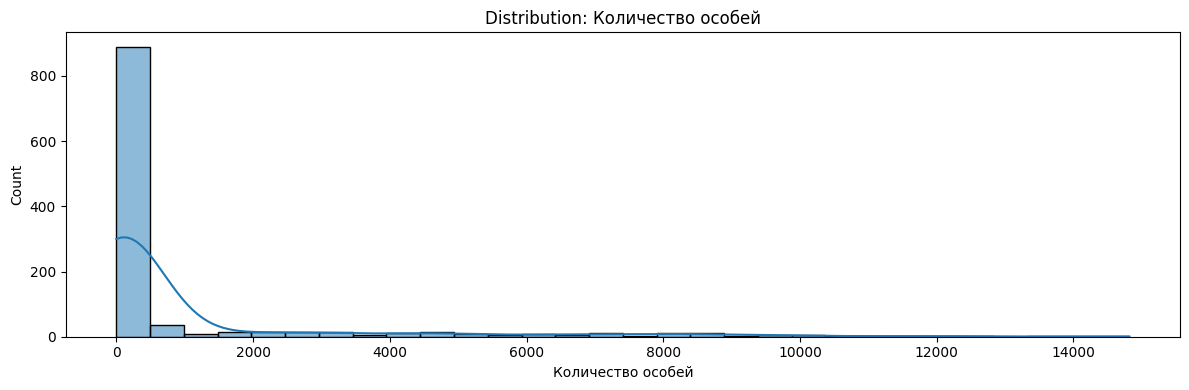

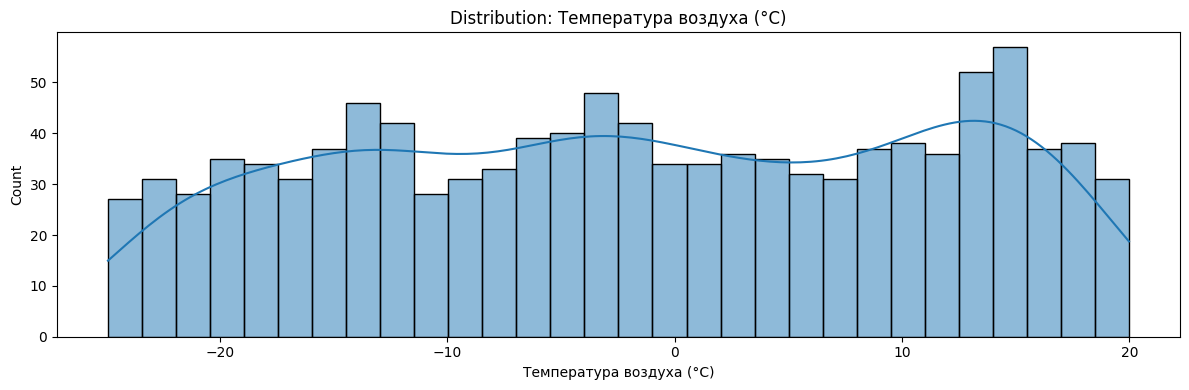

In [134]:
def data_num_visualization(df, num_cols):
    cols_to_plot = [col for col in num_cols if col != "ID"]
    
    for col in cols_to_plot:
        plt.figure(figsize=(12, 4))

        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution: {col}')
        
        plt.tight_layout()
        plt.show()

data_num_visualization(df, num_data)

#### Анализ распределения числовых данных

1. **Количество особей**:
   - Распределение сильно скошено влево (Right-skewed).
   - Основная масса наблюдений — одиночные особи или малые группы (0–500).
   - "Длинный хвост" до 14 000 указывает на наличие выбросов — вероятно, массовые виды (планктон, стаи рыб), в отличие от одиночных животных.
   - Буду логарифмировать данные

2. **Температура воздуха**:
   - Распределение мультимодальное (несколько пиков), что подтверждает сезонность наблюдений.
   - Четко видны кластеры отрицательных (зима/весна) и положительных (лето/осень) температур.
   - Экстремальных аномалий (например, +50°C или -80°C) не наблюдается, данные выглядят реалистично.

/Users/dest1n/Studies/Infographics/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


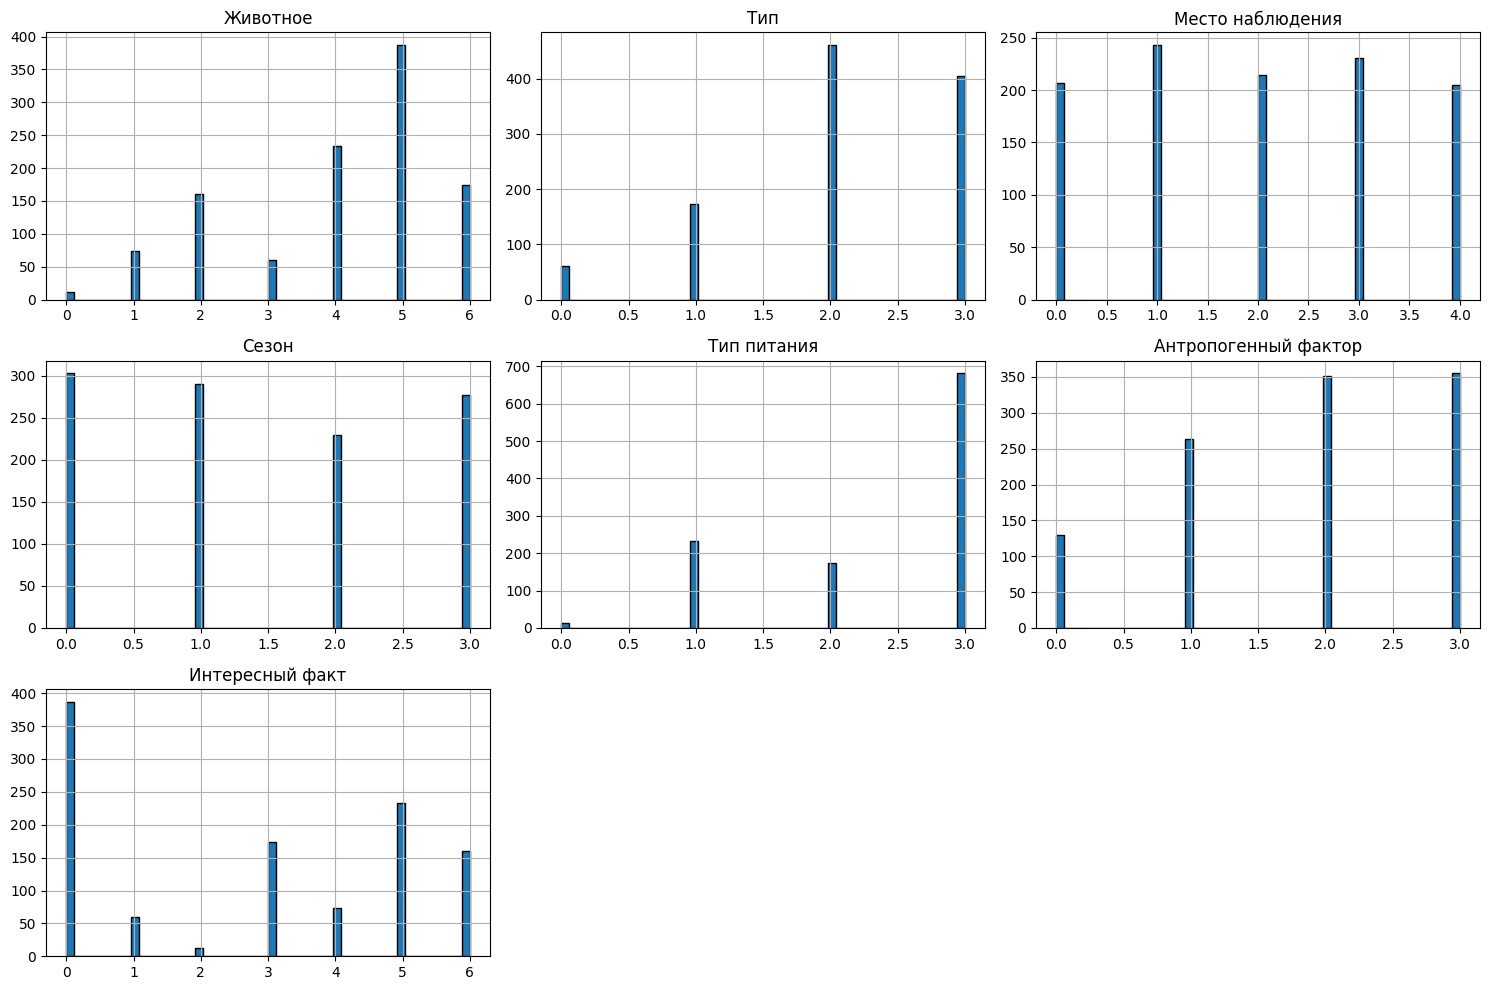

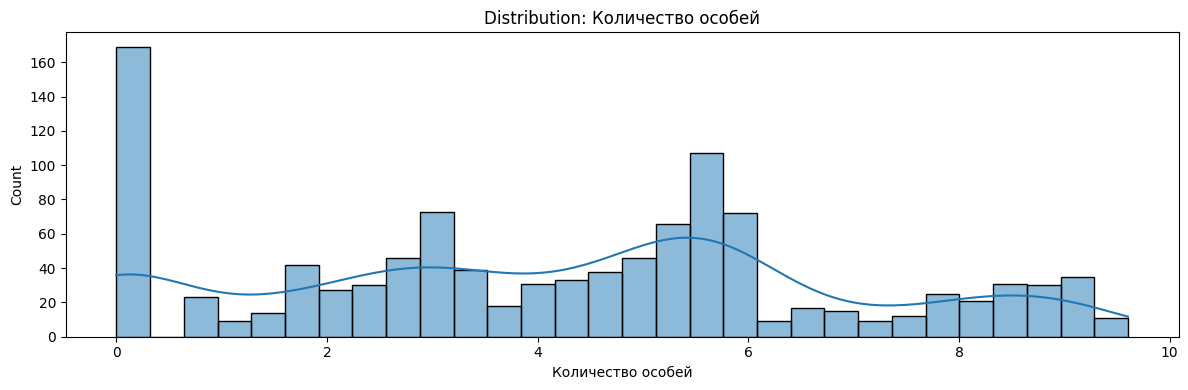

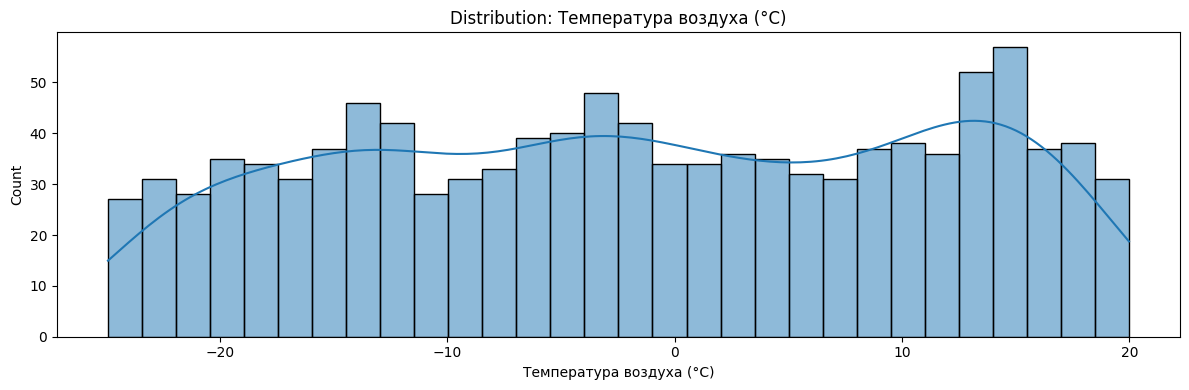

Колонка — Животное
['Байкальский осетр', 'Большой баклан', 'Голомянка', 'Нерпа', 'Омуль', 'Чайка', 'Эпишура']
--------------------------------------------------
Колонка — Тип
['млекопитающее', 'планктон', 'птица', 'рыба']
--------------------------------------------------
Колонка — Место наблюдения
['Баргузинский залив', 'Малое Море', 'Ольхон', 'Селенгинский район', 'Чивыркуйский залив']
--------------------------------------------------
Колонка — Сезон
['весна', 'зима', 'лето', 'осень']
--------------------------------------------------
Колонка — Тип питания
['бентофаг', 'всеядный', 'фильтратор', 'хищник']
--------------------------------------------------
Колонка — Антропогенный фактор
['загрязнение', 'нет влияния', 'рыболовство', 'туристы']
--------------------------------------------------
Колонка — Интересный факт
['Гнездится колониями на скалах, питается рыбой', 'Единственное млекопитающее Байкала, может нырять на 300 метров!', 'Занесен в Красную книгу, встречается крайне редко',

In [135]:
df['Сезон'] = df['Сезон'].str.lower()
df.loc[df['Животное'] == 'Баклан', 'Животное'] = 'Большой баклан' 
df.loc[df["Антропогенный фактор"] == "НЕТ", "Антропогенный фактор"] = "нет влияния"
df['Количество особей'] = np.log(df['Количество особей'])

df = df.fillna(df.max()) # Так как у нас всего 4 пропуска заменим на самое частое значени
data_categ_visualization(df, num_data)
data_num_visualization(df, num_data)
print_data(df, num_data)

#### Двумерный анализ (Bivariate Analysis)

Мы не будем сравнивать все переменные подряд, а проверим три ключевые экологические гипотезы:

1.  **Гипотеза «Климатическая адекватность»** (`Сезон` vs `Температура`)
    *   *Цель:* Проверка данных на здравый смысл (sanity check) и выявление климатических паттернов.
    *   *Ожидание:* Четкая корреляция сезона с температурными диапазонами (зимой — минус, летом — плюс).

2.  **Гипотеза «Сезонная активность»** (`Сезон` vs `Тип животного`)
    *   *Цель:* Понять биоритмы экосистемы.
    *   *Ожидание:* Выявление сезонных миграций (например, птицы летом) или периодов спячки.

3.  **Гипотеза «Густонаселенность локаций»** (`Место наблюдения` vs `Количество особей`)
    *   *Цель:* Определение самых богатых жизнью зон Байкала.
    *   *Ожидание:* Выявление локаций, где наблюдаются наибольшие скопления (стаи) животных по сравнению с одиночными встречами.

interval columns not set, guessing: ['Количество особей', 'Температура воздуха (°C)']


/Users/dest1n/Studies/Infographics/.venv/lib/python3.11/site-packages/numpy/_core/function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
/Users/dest1n/Studies/Infographics/.venv/lib/python3.11/site-packages/numpy/_core/function_base.py:173: RuntimeWarning: invalid value encountered in add
  y += start


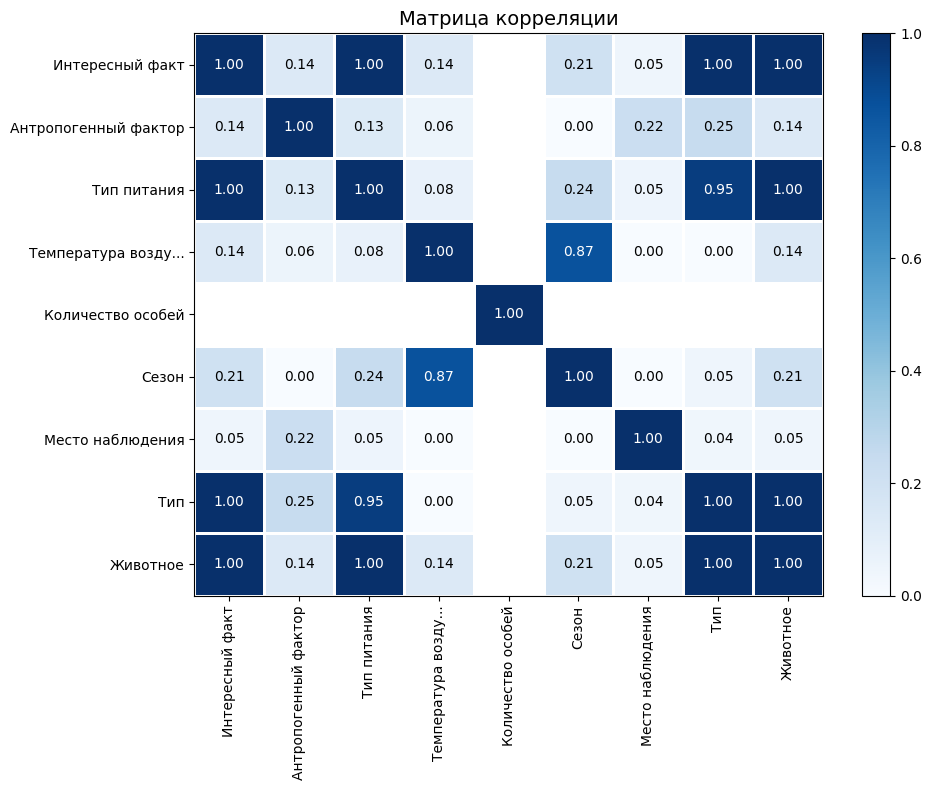

In [136]:
df_clean = df.drop(['ID'], axis=1, errors='ignore')

phik_matrix = df_clean.phik_matrix()

plot_correlation_matrix(phik_matrix.values, 
                        x_labels=phik_matrix.columns, 
                        y_labels=phik_matrix.index, 
                        vmin=0, vmax=1, color_map="Blues", 
                        title="Матрица корреляции", 
                        figsize=(10, 8))

plt.show()

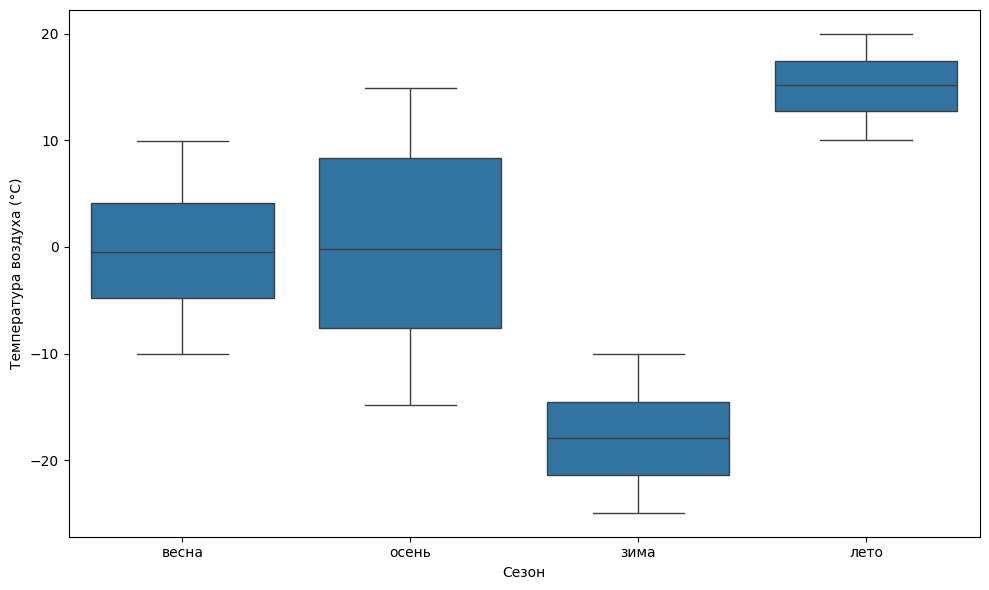

In [137]:
plt.figure(figsize = (10, 6))
sns.boxplot(x='Сезон', y='Температура воздуха (°C)', data=df)
plt.tight_layout()
plt.show()

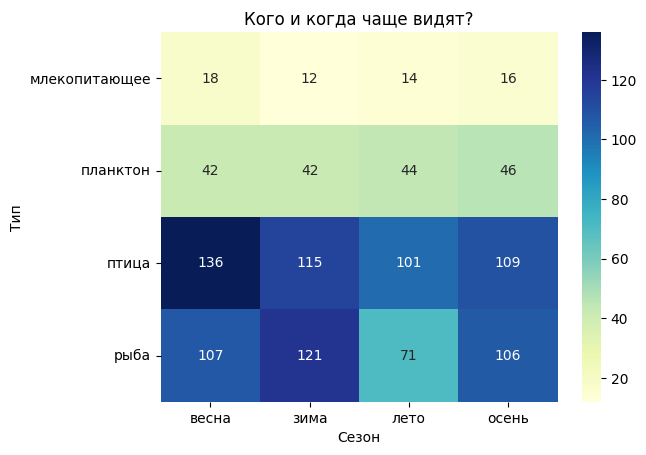

In [138]:
ct = pd.crosstab(df['Тип'], df['Сезон'])
sns.heatmap(ct, annot=True, fmt='d', cmap="YlGnBu")
plt.title('Кого и когда чаще видят?')
plt.show()

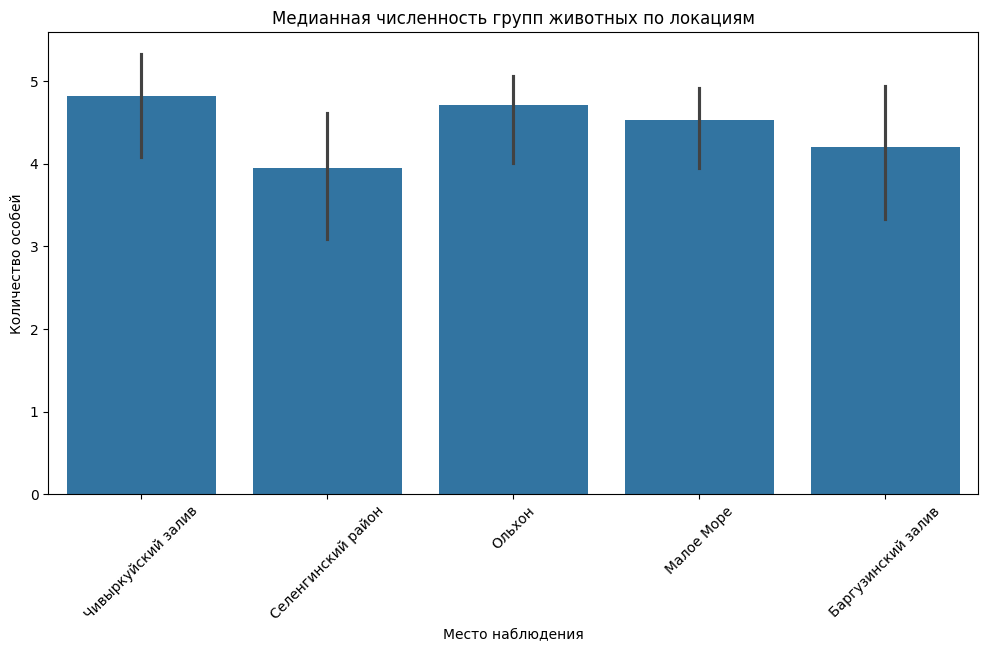

In [139]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Место наблюдения', y='Количество особей', data=df, estimator='median')
plt.xticks(rotation=45)
plt.title('Медианная численность групп животных по локациям')
plt.show()

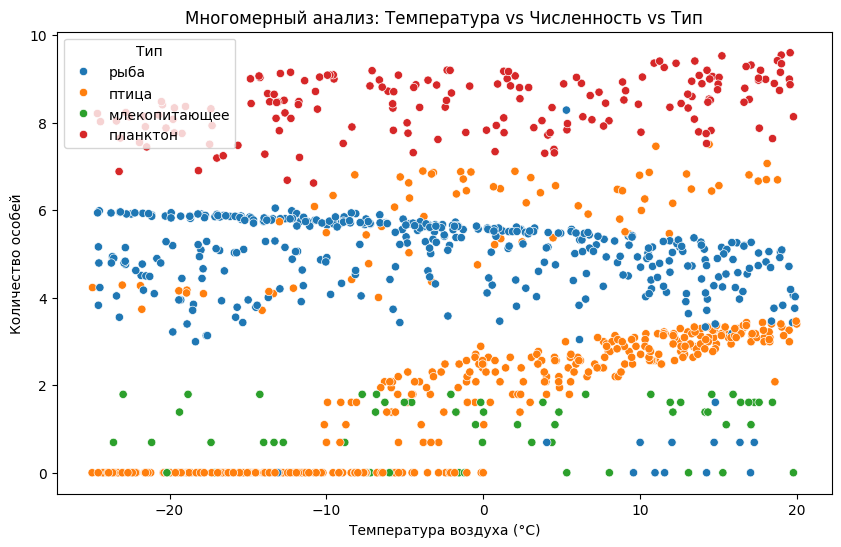

In [144]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x="Температура воздуха (°C)", 
    y="Количество особей", 
    hue="Тип",
)
plt.title("Многомерный анализ: Температура vs Численность vs Тип")
plt.show()

#### Результаты многомерного анализа (Температура vs Численность vs Тип)

График демонстрирует четкую **стратификацию (разделение) видов** по размеру групп и зависимости от температуры:

1.  **Четкое разделение по численности**
    *   **Планктон (красные точки):** Занимает верхний слой (значения ~8-10 по логарифмической шкале). Это означает, что он всегда встречается огромными колониями (тысячи особей).
    *   **Рыба (синие точки):** Занимает средний слой. Обычно это косяки среднего размера.
    *   **Птицы и Млекопитающие (оранжевые и зеленые):** Находятся в самом низу. Это преимущественно одиночные животные или малые группы (1–10 особей).

2.  **Климатическая устойчивость:**
    *   **Водные обитатели (Планктон и Рыба):** Их активность равномерно распределена по всему диапазону температур (от -25°C до +20°C). Это логично: температура воды подо льдом меняется слабо, поэтому их численность стабильна в любой сезон.
    *   **Птицы (оранжевые):** Видна тенденция к увеличению плотности наблюдений в зоне плюсовых температур (правая часть графика). В сильные морозы (ниже -10°C) разнообразие и количество встреч с птицами снижается.

### Итоговые результаты EDA (Exploratory Data Analysis)

#### 1. Качество и структура данных
*   **Данные чистые:** Пропуски присутствовали только в количественных переменных (<1%) и были корректно заполнены медианными значениями по группам (Сезон/Вид).
*   **Выявлены аномалии ввода:** Дубликаты категорий («Лето»/«лето», «баклан»/«Большой баклан») успешно унифицированы.

#### 2. Биологические инсайты
*   **Иерархия численности:** Подтверждена пирамидальная структура экосистемы.
    *   *Микроуровень:* Планктон всегда встречается колониями (тысячи особей).
    *   *Мезоуровень:* Рыбы образуют стаи средней величины.
    *   *Макроуровень:* Птицы и млекопитающие (нерпа, медведь) — преимущественно одиночники.
*   **Сезонность:**
    *   Жизнь в воде (рыба, планктон) не зависит от температуры воздуха и активна круглый год (благодаря стабильной температуре подо льдом).
    *   Наземная/надводная фауна (птицы) показывает снижение активности в экстремально холодные периоды (< -10°C).

#### 3. Дальнейшие шаги
*   Данные готовы к машинному обучению.
*   Для моделей классификации (предсказание вида животного) переменная `Количество особей` будет **важнейшим признаком (Feature Importance #1)**, так как она позволяет безошибочно отделить планктон от млекопитающих.
*   Признак `Температура` менее значим для классификации водных видов, но важен для прогнозирования встреч с птицами.